<a href="https://colab.research.google.com/github/junyongarli/gachon_P_project/blob/main/word_embedding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Word Embedding — NumPy 실습
강의에서 배운 Word Embedding 개념을 **NumPy만으로** 직접 구현합니다.

> 📌 `___` 로 표시된 부분을 채워 넣으세요.


## 환경 준비

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from collections import defaultdict, Counter
import re

plt.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

print("환경 준비 완료")


환경 준비 완료


## One-hot 인코딩 & Lookup Table

### 개념 정리

**원-핫 인코딩** : 단어를 단어 집합 크기의 벡터로 표현하며, 해당 단어 위치만 1입니다.  
→ 희소(Sparse), 단어 간 의미 관계 없음

**Lookup Table** : 원-핫 벡터와 가중치 행렬 $W$의 곱은 결국 $W$의 **해당 행을 그대로 읽어오는 것**과 같습니다.

$$\text{one-hot}(i) \cdot W = W[i, :]$$

이게 **임베딩 레이어(Embedding Layer)** 의 본질.


### 단어 사전 구축 & 원-핫 인코딩

In [23]:
vocab_sentence = "what will the fat cat sit on the mat"
vocab_tokens   = vocab_sentence.split()

vocab    = sorted(set(vocab_tokens))
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

print(f"단어 집합 크기 V = {len(vocab)}")
print(f"word2idx: {word2idx}")

def to_onehot(word: str, word2idx: dict) -> np.ndarray:
    """단어를 원-핫 벡터(V,)로 변환합니다."""
    V   = len(word2idx)
    # TODO: 1) V차원의 zero-vector(변수 vec)를 만들고 2) word2idx를 이용해 단어에 해당하는 인덱스를 1로 설정하세요.
    vec = np.zeros(V)
    vec[word2idx[word]] = 1.0
    return vec

print(f"'cat' 원-핫 벡터:\n{to_onehot('cat', word2idx)}")


단어 집합 크기 V = 8
word2idx: {'cat': 0, 'fat': 1, 'mat': 2, 'on': 3, 'sit': 4, 'the': 5, 'what': 6, 'will': 7}
'cat' 원-핫 벡터:
[1. 0. 0. 0. 0. 0. 0. 0.]


### Lookup Table 구현

In [24]:
V = len(vocab)
M = 5   # 임베딩 차원 (하이퍼파라미터)

np.random.seed(0)
W_embed = np.random.randn(V, M) * 0.1

def lookup(word: str, word2idx: dict, W: np.ndarray) -> np.ndarray:
    """단어 인덱스로 임베딩 벡터를 직접 참조합니다 (Lookup Table)."""
    # TODO: word2idx를 사용하여 W에서 해당 단어(word)의 행을 반환하세요. (원-핫 행렬곱 불필요)
    return W[word2idx[word]]

# 검증: 원-핫 행렬곱과 Lookup이 같은 결과인지 확인
word = 'cat'
via_lookup  = lookup(word, word2idx, W_embed)
via_matmul  = to_onehot(word, word2idx) @ W_embed

print(f"Lookup 결과:   {via_lookup.round(4)}")
print(f"행렬곱 결과:   {via_matmul.round(4)}")
print(f"두 결과 동일? {np.allclose(via_lookup, via_matmul)}")
print()
print("Lookup은 원-핫 벡터의 행렬곱을 '인덱스 참조'로 대체 → 연산량 절감")


Lookup 결과:   [0.1764 0.04   0.0979 0.2241 0.1868]
행렬곱 결과:   [0.1764 0.04   0.0979 0.2241 0.1868]
두 결과 동일? True

Lookup은 원-핫 벡터의 행렬곱을 '인덱스 참조'로 대체 → 연산량 절감


---
## 1. Word2Vec — CBOW 간이 구현

### 개념 정리

**CBOW (Continuous Bag of Words)** : **주변 단어**들의 임베딩 평균으로 **중심 단어**를 예측합니다.

```
주변 단어 → Lookup → 평균(v̄) → 출력층(W') → Softmax → 중심 단어 예측
```

**학습 데이터** : Sliding Window로 (주변 단어들, 중심 단어) 쌍을 자동 생성합니다.

$$\hat{y} = \text{softmax}(W'^T \cdot \bar{v}), \quad \bar{v} = \frac{1}{2n}\sum_{c} e_c$$


### CBOW 학습 데이터 생성 (Sliding Window)

In [25]:
def build_cbow_dataset(tokens: list, window: int, word2idx: dict) -> list:
    """
    Sliding Window로 CBOW 학습 데이터를 구성합니다.
    반환: [(context_indices, center_idx), ...] 형태의 리스트
    """
    dataset = []
    for i in range(window, len(tokens) - window):
        # TODO: word2idx를 사용해서 중심 단어 인덱스와 주변 단어 인덱스 리스트를 구성하세요.
        center_idx  = word2idx[tokens[i]]   # i 번째 token에 해당하는 인덱스
        ctx_indices = [
            word2idx[tokens[j]]
            for j in range(i - window, i + window + 1)
            if j != i
        ]   # i 번째 앞뒤 window 크기만큼에 해당하는 단어 인덱스 리스트
        dataset.append((ctx_indices, center_idx))
    return dataset


sample_tokens = vocab_sentence.split()
cbow_data     = build_cbow_dataset(sample_tokens, window=2, word2idx=word2idx)

print(f"데이터셋 크기: {len(cbow_data)}개 샘플")
print("첫 3개 샘플 (ctx_indices → center_idx):")
for ctx, ctr in cbow_data[:3]:
    ctx_words = [idx2word[i] for i in ctx]
    ctr_word  = idx2word[ctr]
    print(f"  {ctx_words} → '{ctr_word}'")

데이터셋 크기: 5개 샘플
첫 3개 샘플 (ctx_indices → center_idx):
  ['what', 'will', 'fat', 'cat'] → 'the'
  ['will', 'the', 'cat', 'sit'] → 'fat'
  ['the', 'fat', 'sit', 'on'] → 'cat'


### CBOW Forward Pass

In [26]:
def softmax(z: np.ndarray) -> np.ndarray:
    z = z - z.max() # overflow 차단 때문, 결과는 똑같음.
    e = np.exp(z)
    return e / e.sum()

def cbow_forward(ctx_indices: list, W_in: np.ndarray, W_out: np.ndarray) -> tuple:
    """
    CBOW Forward Pass
    W_in  : 입력 임베딩 행렬  (V × M)
    W_out : 출력 가중치 행렬  (M × V)
    반환  : (v_bar, y_hat)
    """
    # TODO : context index (ctx_indices)와 Look up table (W_in)을 사용해서 주변 단어 임베딩을 ctx_vecs에 할당 하세요.
    ctx_vecs = W_in[ctx_indices]

    # TODO : ctx_vec의 평균을 구하세요
    v_bar    = ctx_vecs.mean(axis=0)

    # TODO : 출력층의 weight matrix인 W_out을 사용하여 출력층 계산 후 softmax를 적용 하세요.
    z     = v_bar @ W_out
    y_hat = softmax(z)      # 위에 선언된 softmax() 함수 사용

    return v_bar, y_hat

V_sz, M_sz = len(vocab), 4
np.random.seed(1)
W_in  = np.random.randn(V_sz, M_sz) * 0.01
W_out = np.random.randn(M_sz, V_sz) * 0.01

ctx_idx, ctr_idx = cbow_data[0]
v_bar, y_hat = cbow_forward(ctx_idx, W_in, W_out)

print(f"v_bar shape : {v_bar.shape}  (기댓값: ({M_sz},))")
print(f"y_hat shape : {y_hat.shape}  (기댓값: ({V_sz},))")
print(f"y_hat 합    : {y_hat.sum():.6f}  (기댓값: 1.0)")

v_bar shape : (4,)  (기댓값: (4,))
y_hat shape : (8,)  (기댓값: (8,))
y_hat 합    : 1.000000  (기댓값: 1.0)


### CBOW 학습 루프 (Cross-Entropy + Backprop)

In [27]:
def cbow_train(dataset: list, V: int, M: int, lr: float = 0.05, epochs: int = 1000):
    """CBOW를 학습하고 (W_in, W_out, loss_history)를 반환합니다."""
    np.random.seed(42)
    W_in  = np.random.randn(V, M) * 0.01
    W_out = np.random.randn(M, V) * 0.01
    loss_history = []

    for epoch in range(epochs):
        total_loss = 0.0
        for ctx_indices, ctr_idx in dataset:
            # TODO: 현재 cbow model에 대한 forward 연산
            v_bar, y_hat = cbow_forward(ctx_indices, W_in, W_out)

            # TODO : Cross-Entropy Loss: -log(y_hat[ctr_idx])
            y_hat_c = np.clip(y_hat, 1e-7, 1.0) # Loss 계산시 부동 소수점 오차에 의한 에러 차단
            loss = -np.log(y_hat_c[ctr_idx])
            total_loss += loss

            # 출력층 gradient: dz = y_hat - one_hot(ctr_idx)
            dz = y_hat.copy()
            dz[ctr_idx] -= 1

            # W_out gradient 및 업데이트
            dW_out = np.outer(v_bar, dz)

            # v_bar gradient (은닉층으로 전달)
            dv_bar = W_out @ dz

            W_out -= lr * dW_out

            # W_in의 해당 행들 업데이트
            for idx in ctx_indices:
                W_in[idx] -= lr * dv_bar / len(ctx_indices)

        avg_loss = total_loss / len(dataset)
        loss_history.append(avg_loss)
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d} | Loss = {avg_loss:.4f}")

    return W_in, W_out, loss_history

print("CBOW 학습 시작...")
W_in_trained, W_out_trained, loss_hist = cbow_train(
    cbow_data, V=V_sz, M=4, lr=0.05, epochs=100)

CBOW 학습 시작...
Epoch  20 | Loss = 2.0793
Epoch  40 | Loss = 2.0790
Epoch  60 | Loss = 2.0784
Epoch  80 | Loss = 2.0768
Epoch 100 | Loss = 2.0726


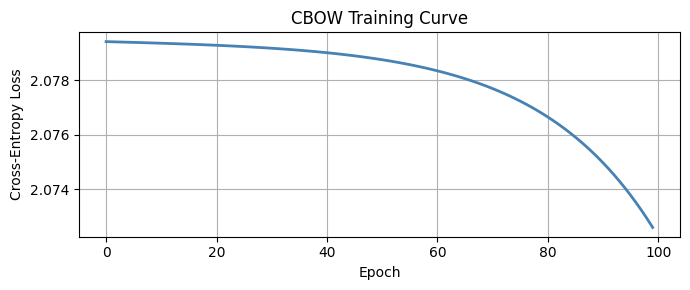

In [28]:
# 학습 곡선 시각화 (수정 불필요)
plt.figure(figsize=(7, 3))
plt.plot(loss_hist, color='steelblue', linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Cross-Entropy Loss')
plt.title('CBOW Training Curve'); plt.grid(True)
plt.tight_layout(); plt.show()


---
## 2. FastText — Subword n-gram

### 개념 정리

**FastText**는 단어를 **글자(character) 단위 n-gram**으로 분리해 학습합니다.  
OOV·오타 단어도 subword를 공유하면 유사한 벡터를 얻을 수 있습니다.

**처리 과정**:
1. 단어 양쪽에 `<` / `>` 추가 (독립 단어와 n-gram 구분)
2. min_n ~ max_n 범위의 character n-gram 추출
3. 단어 벡터 = 모든 subword 임베딩의 **합**

예) `eating` (n=3~4) → `<ea`, `eat`, `ati`, ... , `<eating>`


### 문제 5-1. Character N-gram 추출

In [29]:
def get_char_ngrams(word: str, min_n: int = 3, max_n: int = 6) -> list:
    """
    FastText 방식으로 단어의 character n-gram을 추출합니다.
    1. 단어에 '<', '>' 추가
    2. min_n ~ max_n 범위의 char n-gram 추출
    3. 원본 단어('<word>') 포함
    반환: 중복 제거된 subword 리스트
    """
    # TODO : 단어에 < > 추가
    bounded = "<" + word + ">"

    # TODO : min_n ~ max_n 범위의 char n-gram 추출
    subwords = set()
    for n in range(min_n, max_n + 1):
        for i in range(len(bounded) - n + 1):
            subwords.add(bounded[i:i+n])

    # TODO : 원본 단어 추가 ('<word>' 형태)
    subwords.add(bounded)

    return sorted(subwords)

# 검증
print("'eating' subwords (n=3~4):")
for sw in get_char_ngrams('eating', min_n=3, max_n=4):
    print(f"  {sw}")
print(f"\n총 {len(get_char_ngrams('eating', 3, 4))}개")


'eating' subwords (n=3~4):
  <ea
  <eat
  <eating>
  ati
  atin
  eat
  eati
  ing
  ing>
  ng>
  tin
  ting

총 12개


### OOV 단어 처리 시뮬레이션

In [30]:
train_words = ['eat', 'eating', 'eaten', 'eater', 'fast', 'faster']

subword_vocab = {}
for w in train_words:
    for sw in get_char_ngrams(w, 3, 4):
        if sw not in subword_vocab:
            subword_vocab[sw] = len(subword_vocab)

print(f"subword 사전 크기: {len(subword_vocab)}개")

np.random.seed(0)
SW_embed = np.random.randn(len(subword_vocab), 5) * 0.1 # 테스트를 위한 랜덤 단어 임베딩

def fasttext_word_vector(word: str, subword_vocab: dict, SW_embed: np.ndarray) -> np.ndarray:
    """단어를 subword로 분리 → subword 임베딩의 합을 반환합니다.
    훈련 데이터에 없는 subword는 무시합니다.
    """
    subwords = get_char_ngrams(word, 3, 4)
    vecs = [SW_embed[subword_vocab[sw]] for sw in subwords if sw in subword_vocab]
    if not vecs:
        return np.zeros(SW_embed.shape[1])
    # TODO: subword 임베딩 벡터들의 합을 계산하세요.
    return np.sum(vecs, axis=0)

oov_word = 'eats'
print(f"\n'{oov_word}'는 훈련 vocabulary에 없음: {oov_word not in train_words}")
vec_oov = fasttext_word_vector(oov_word, subword_vocab, SW_embed)
vec_eat = fasttext_word_vector('eat',   subword_vocab, SW_embed)
print(f"'{oov_word}' 벡터: {vec_oov.round(4)}")
print(f"'eat'   벡터: {vec_eat.round(4)}")

shared = set(get_char_ngrams(oov_word,3,4)) & set(get_char_ngrams('eat',3,4))
print(f"\n공유 subword: {shared}")
print("공유 subword가 있으면 OOV 단어도 유사한 벡터를 얻을 수 있습니다!")


subword 사전 크기: 39개

'eats'는 훈련 vocabulary에 없음: True
'eats' 벡터: [-0.1766  0.2004  0.1692  0.1396  0.4548]
'eat'   벡터: [-0.2743  0.4998  0.2061  0.3363  0.5607]

공유 subword: {'eat', '<eat', '<ea'}
공유 subword가 있으면 OOV 단어도 유사한 벡터를 얻을 수 있습니다!


### 오타 강건성 확인 (Jaccard 유사도)

In [31]:
def subword_overlap_ratio(w1: str, w2: str, min_n=3, max_n=4) -> float:
    """두 단어의 subword 교집합 / 합집합 비율 (Jaccard 유사도)"""
    s1 = set(get_char_ngrams(w1, min_n, max_n))
    s2 = set(get_char_ngrams(w2, min_n, max_n))
    # TODO: Jaccard 유사도를 계산하세요. |s1 ∩ s2| / |s1 ∪ s2|
    return len(s1 & s2) / len(s1 | s2)

pairs = [
    ('apple',  'appple'),   # 오타 (p 하나 추가)
    ('apple',  'aple'),     # 오타 (p 하나 제거)
    ('apple',  'orange'),   # 전혀 다른 단어
    ('eating', 'eaten'),    # 같은 어근
]

print(f"{'단어1':10s}  {'단어2':10s}  {'Jaccard':>10s}")
print("-" * 36)
for w1, w2 in pairs:
    ratio = subword_overlap_ratio(w1, w2)
    print(f"{w1:10s}  {w2:10s}  {ratio:.4f}")

print("\n오타 단어도 높은 subword 중복률 → FastText가 오타에 강건한 이유")


단어1         단어2            Jaccard
------------------------------------
apple       appple      0.5714
apple       aple        0.2857
apple       orange      0.0000
eating      eaten       0.1579

오타 단어도 높은 subword 중복률 → FastText가 오타에 강건한 이유


---
## 3. GloVe — 동시 등장 행렬

### 개념 정리

**GloVe**는 전체 말뭉치의 **동시 등장 통계**를 활용합니다.

**Co-occurrence Matrix** $X$: $X_{ij}$ = 단어 $i$의 윈도우 안에서 단어 $j$가 등장한 횟수

**GloVe 목적함수**:
$$J = \sum_{i,j} f(X_{ij}) \left( v_i \cdot v_j + b_i + b_j - \log X_{ij} \right)^2$$

- $f(X_{ij})$ : 빈도가 낮으면 낮은 가중치, 너무 높으면 1로 상한 제한


### 동시 등장 행렬 구축

In [32]:
glove_corpus = [
    "I like deep learning",
    "I like NLP",
    "I enjoy flying",
]

glove_tokens_list = [sent.lower().split() for sent in glove_corpus]
all_glove_tokens  = [t for sent in glove_tokens_list for t in sent]
glove_vocab       = sorted(set(all_glove_tokens))
g2i = {w: i for i, w in enumerate(glove_vocab)}
V_g = len(glove_vocab)

print(f"단어 집합: {glove_vocab}")

def build_cooccurrence_matrix(token_lists: list, word2idx: dict, window: int = 1) -> np.ndarray:
    """
    윈도우 기반 동시 등장 행렬(X)을 구축합니다.
    """
    V = len(word2idx)
    X = np.zeros((V, V)) # 동시 등장 행렬

    for tokens in token_lists:
        for t, token in enumerate(tokens):
            i = word2idx[token] # 중심 단어 index
            for delta in range(-window, window + 1):
                if delta == 0:
                    continue
                j_pos = t + delta
                if 0 <= j_pos < len(tokens):
                    j = word2idx[tokens[j_pos]] # 주변 단어 index
                    # TODO: 동시 등장 카운트를 증가시키세요.
                    X[i, j] += 1
    return X

X_cooc = build_cooccurrence_matrix(glove_tokens_list, g2i, window=1)

print("\n동시 등장 행렬 (window=1):")
print(f"{'':10s}", end='')
for w in glove_vocab:
    print(f"{w:10s}", end='')
print()
for i, w in enumerate(glove_vocab):
    print(f"{w:10s}", end='')
    for j in range(V_g):
        print(f"{int(X_cooc[i,j]):10d}", end='')
    print()


단어 집합: ['deep', 'enjoy', 'flying', 'i', 'learning', 'like', 'nlp']

동시 등장 행렬 (window=1):
          deep      enjoy     flying    i         learning  like      nlp       
deep               0         0         0         0         1         1         0
enjoy              0         0         1         1         0         0         0
flying             0         1         0         0         0         0         0
i                  0         1         0         0         0         2         0
learning           1         0         0         0         0         0         0
like               1         0         0         2         0         0         1
nlp                0         0         0         0         0         1         0


### 동시 등장 확률 계산

In [33]:
def cooccurrence_prob(X: np.ndarray, i: int, j: int) -> float:
    """P(j | i) = X[i, j] / sum(X[i, :])"""
    # TODO: 동시 등장 확률을 계산하고 return하세요. sum(X[i, :])이 0일 경우 0.0을 return하는 예외 처리를 추가하세요.
    row_sum = np.sum(X[i, :])
    if row_sum == 0:
        return 0.0

    return X[i, j] / row_sum


i_idx    = g2i['i']
like_idx = g2i['like']
enj_idx  = g2i['enjoy']
nlp_idx  = g2i['nlp']

print(f"P(like  | i) = {cooccurrence_prob(X_cooc, i_idx, like_idx):.4f}")
print(f"P(enjoy | i) = {cooccurrence_prob(X_cooc, i_idx, enj_idx):.4f}")
print(f"P(nlp   | i) = {cooccurrence_prob(X_cooc, i_idx, nlp_idx):.4f}")
print()
print("동시 등장 확률의 비율이 단어 간 관계를 포착합니다 (GloVe 핵심 아이디어)")

P(like  | i) = 0.6667
P(enjoy | i) = 0.3333
P(nlp   | i) = 0.0000

동시 등장 확률의 비율이 단어 간 관계를 포착합니다 (GloVe 핵심 아이디어)


### 가중치 함수 f(X) 구현

/tmp/ipykernel_4932/2856323836.py:24: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_4932/2856323836.py:24: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_4932/2856323836.py:24: UserWarning: Glyph 46321 (\N{HANGUL SYLLABLE DEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_4932/2856323836.py:24: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_4932/2856323836.py:24: UserWarning: Glyph 54943 (\N{HANGUL SYLLABLE HOES}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_4932/2856323836.py:24: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_4932/2856323836.py:24: UserWarning: Glyph 4403

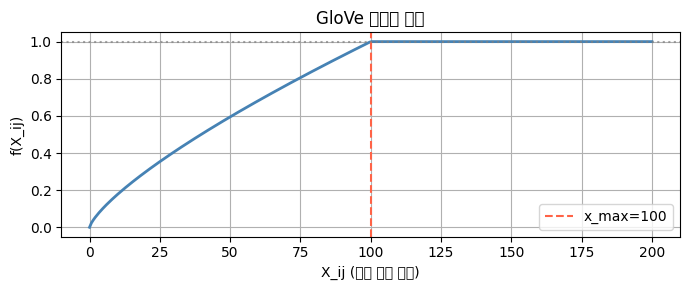

빈도가 낮으면 낮은 가중치 (신뢰하기 어려운 통계)
x_max 이상이면 가중치 1 상한 (the 같은 극빈출 단어 지배 방지)


In [34]:
def glove_weight(x: float, x_max: float = 100.0, alpha: float = 0.75) -> float:
    """
    GloVe 가중치 함수
    희귀 쌍은 낮은 가중치, 과빈출 쌍은 1.0 상한 제한
    """
    # TODO: 조건에 따라 가중치를 반환하세요.
    if x < x_max:
        return (x / x_max) ** alpha
    else:
        return 1.0

# 가중치 함수 시각화
x_vals = np.linspace(0, 200, 300)
w_vals = [glove_weight(x) for x in x_vals]

plt.figure(figsize=(7, 3))
plt.plot(x_vals, w_vals, color='steelblue', linewidth=2)
plt.axvline(100, color='tomato', linestyle='--', label='x_max=100')
plt.axhline(1.0, color='gray',   linestyle=':',  alpha=0.7)
plt.xlabel('X_ij (동시 등장 횟수)')
plt.ylabel('f(X_ij)')
plt.title('GloVe 가중치 함수')
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

print("빈도가 낮으면 낮은 가중치 (신뢰하기 어려운 통계)")
print("x_max 이상이면 가중치 1 상한 (the 같은 극빈출 단어 지배 방지)")


---
## 정리

| 방법 | 핵심 아이디어 | 장점 | 한계 |
|------|-------------|------|------|
| **N-gram LM** | 최근 n-1개 단어로 확률 추정 | 구현 간단 | 희소 문제 |
| **Word2Vec CBOW** | 주변 단어 평균 → 중심 단어 예측 | 빠른 학습, 의미 반영 | OOV |
| **FastText** | Subword n-gram의 합 | OOV·오타 강건 | 계산량 증가 |
| **GloVe** | 전역 동시 등장 통계 활용 | 전체 말뭉치 반영 | OOV |

### CBOW 학습 패턴 요약
```
① Lookup(W_in) → ctx 임베딩들의 평균 v̄
② W_out.T @ v̄ → softmax → ŷ
③ Cross-Entropy Loss = -log(ŷ[center])
④ Backprop: dz → dW_out / dv̄ → W_in 행 업데이트
```
